<img src="http://imgur.com/1ZcRyrc.png" style="float: left; margin: 20px; height: 55px">

# ARIMA & SARIMA Lab

---


## Learning Objectives

### Core
- Test a time series for stationarity and determine the order of differencing (d)
- Use ACF/PACF plots to reason about AR and MA terms
- Fit an ARIMA model, forecast, and evaluate it
- Detect seasonality in a series and fit a SARIMA model
- Compare ARIMA vs. SARIMA performance on the same data and explain why one wins

### Target
- Use `auto_arima` to search for (p,d,q) and seasonal (P,D,Q,m) orders
- Produce forecasts with confidence intervals


## Scenario

You are a data scientist and were given the monthly airline passenger counts. Your manager wants a short-term forecast, and wants to know whether a simple ARIMA model is good enough or whether the extra complexity of SARIMA is worth it.

You will build both models on the same data and test which model is better.


## 0. Setup

In [4]:
# %pip install pmdarima

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.set_printoptions(precision=4)
sns.set(font_scale=1.5)
plt.style.use('fivethirtyeight')

%matplotlib inline
%config InlineBackend.figure_format = 'retina'


In [6]:
from statsmodels.tsa.stattools import acf, pacf, adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tools.eval_measures import rmse
from pmdarima import auto_arima


<div class="alert alert-info"><strong>What is the below function?:</strong> Function for running the augmented Dickey-Fuller test (adfuller).</div>

In [7]:
def adf_test(series, title=''):
    """
    Pass in a time series and an optional title, returns an ADF report
    """
    print(f'Augmented Dickey-Fuller Test: {title}')
    result = adfuller(series.dropna(),autolag='AIC') # .dropna() handles differenced data
    
    labels = ['ADF test statistic','p-value','# lags used','# observations']
    out = pd.Series(result[0:4],index=labels)

    for key,val in result[4].items():
        out[f'critical value ({key})']=val
        
    print(out.to_string())          # .to_string() removes the line "dtype: float64"
    
    if result[1] <= 0.05:
        print("Strong evidence against the null hypothesis")
        print("Reject the null hypothesis")
        print("Data has no unit root and is stationary")
    else:
        print("Weak evidence against the null hypothesis")
        print("Fail to reject the null hypothesis")
        print("Data has a unit root and is non-stationary")


<div class="alert alert-info"><strong>What is the below function?:</strong> plot ACF and PACF beside each other.</div>

In [8]:
def autocorr_plots(y, lags=None):
    fig, ax = plt.subplots(ncols=2, figsize=(12, 4), sharey=True)
    plot_acf(y, lags=lags, ax=ax[0])
    plot_pacf(y, lags=lags, ax=ax[1])
    return fig, ax


## 1. Load and inspect the data

This is historical monthly airline passenger counts (in thousands).

In [9]:
# 1a. Load the dataset, parsing the 'month' column as dates
df = pd.read_csv('airline_passengers.csv', parse_dates=['month'])
df.head()

,month,thousands_of_passengers
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121


In [10]:
# 1b. Set 'month' as an Index and set the frequency to Monthly-Start (use resamling).
df.set_index('month', inplace=True)
df = df.resample('MS').mean()
df.head()

,thousands_of_passengers
month,
1949-01-01,112.0
1949-02-01,118.0
1949-03-01,132.0
1949-04-01,129.0
1949-05-01,121.0


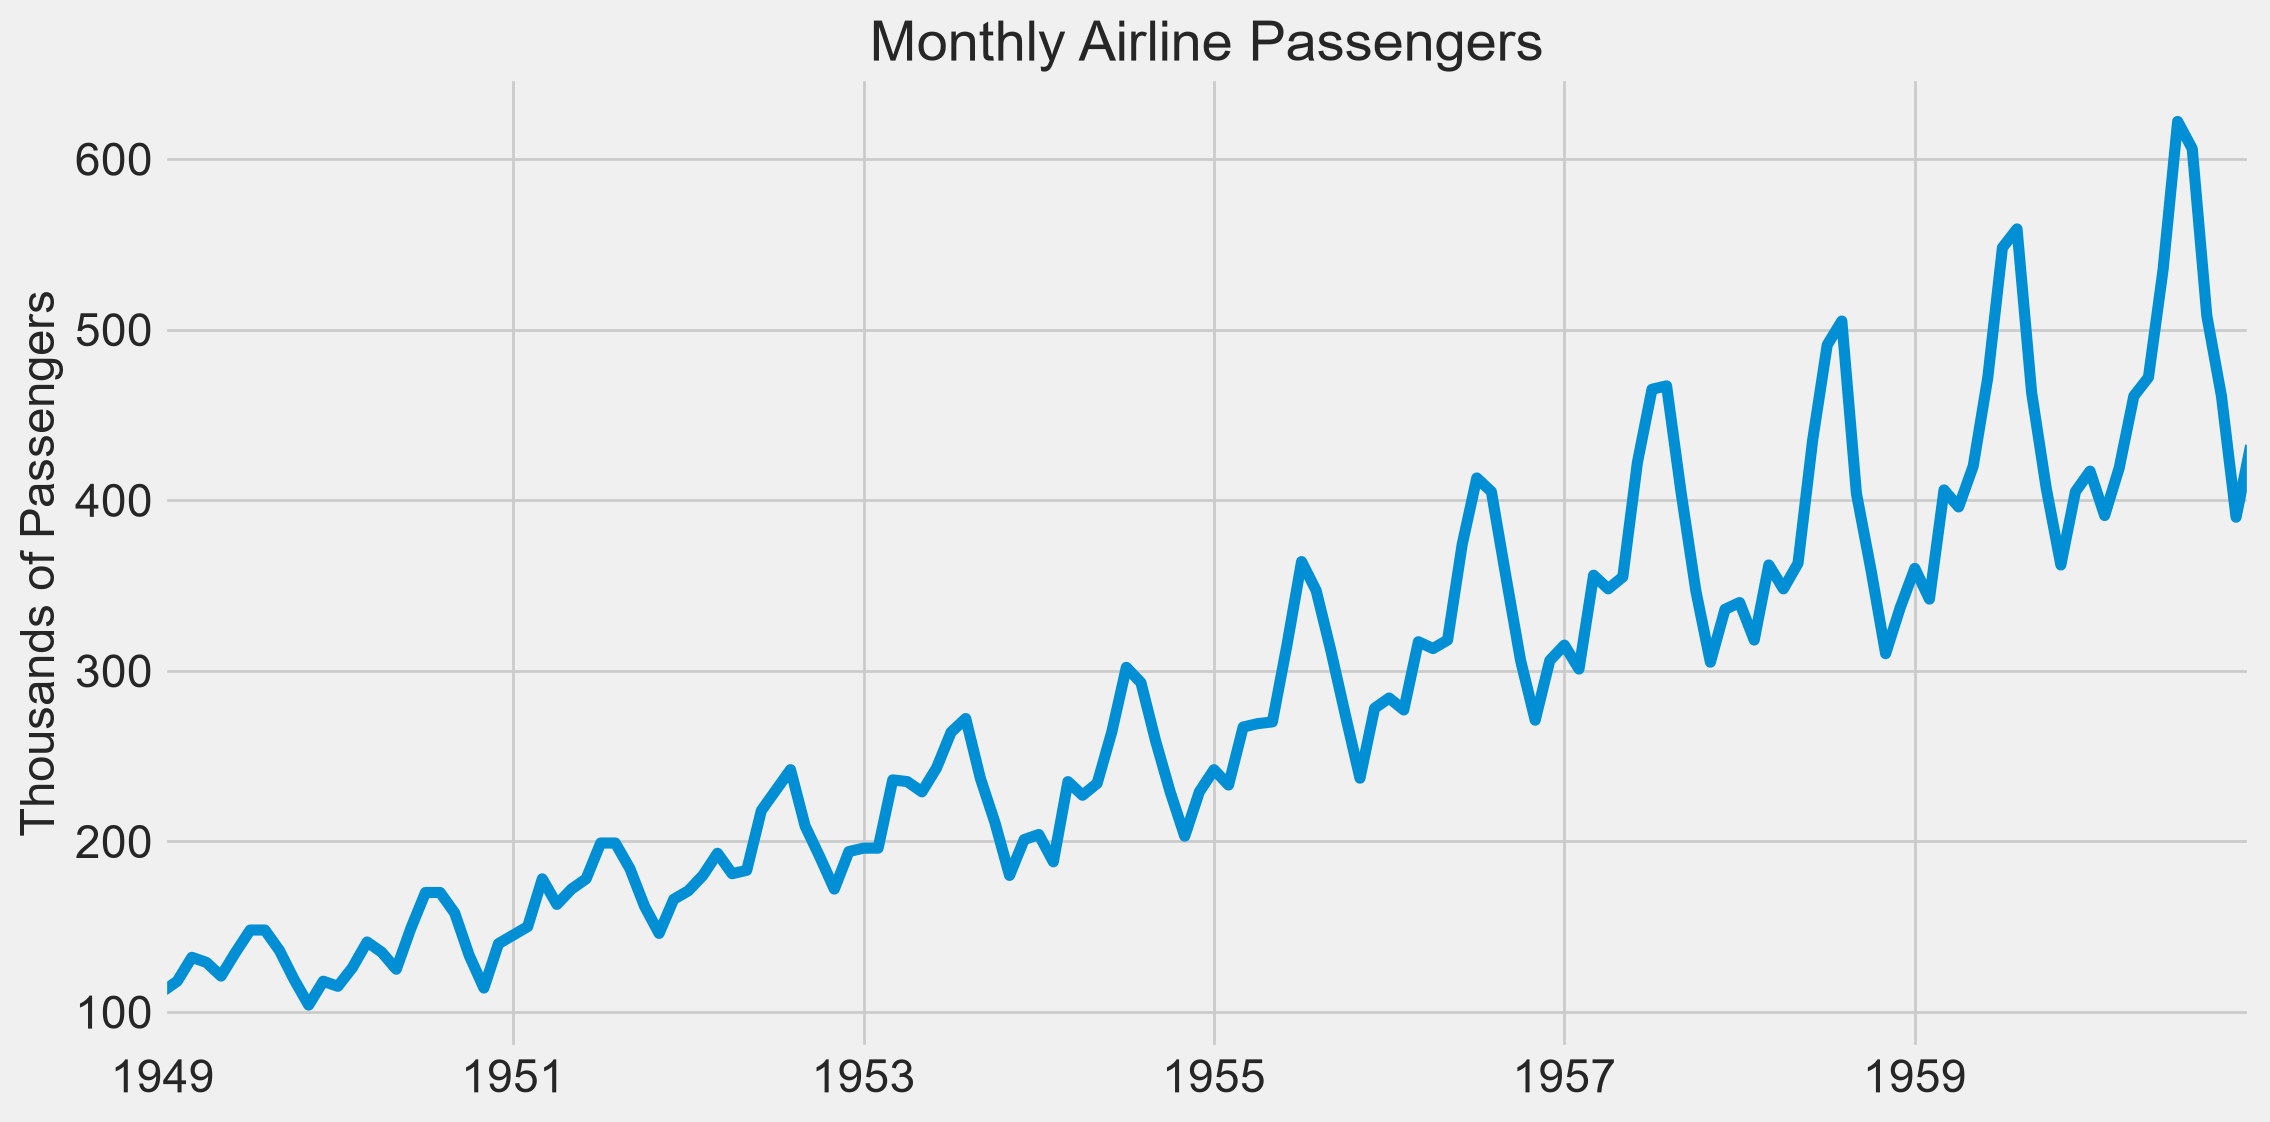

In [11]:
# 1c. Plot the full series and look at shape.
title = 'Monthly Airline Passengers'
ylabel = 'Thousands of Passengers'
xlabel = ''

ax = df['thousands_of_passengers'].plot(figsize=(12,6), title=title)
ax.autoscale(axis='x', tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel);

---
# Part A - ARIMA

We'll start simple: treat this as a general time series and build a non-seasonal ARIMA model. Follow the same workflow: 

> **Stationarity -> Differencing -> ACF/PACF -> Fit -> Evaluate**.


### A1. Check stationarity

In [12]:
# Run adf_test on the passenger series. Is it stationary?
adf_test(df['thousands_of_passengers'], title='Airline Passengers - Original')

Augmented Dickey-Fuller Test: Airline Passengers - Original
ADF test statistic        0.815369
p-value                   0.991880
# lags used              13.000000
# observations          130.000000
critical value (1%)      -3.481682
critical value (5%)      -2.884042
critical value (10%)     -2.578770
Weak evidence against the null hypothesis
Fail to reject the null hypothesis
Data has a unit root and is non-stationary


### A2. Difference until stationary

If the series isn't stationary, difference it (`.diff()`) and re-run the ADF test. Keep track of how many differences it took - that's your `d`.

In [13]:
# Difference once and re-test
df['diff_1'] = df['thousands_of_passengers'].diff()
adf_test(df['diff_1'], title='Airline Passengers - 1st Difference')

Augmented Dickey-Fuller Test: Airline Passengers - 1st Difference
ADF test statistic       -2.829267
p-value                   0.054213
# lags used              12.000000
# observations          130.000000
critical value (1%)      -3.481682
critical value (5%)      -2.884042
critical value (10%)     -2.578770
Weak evidence against the null hypothesis
Fail to reject the null hypothesis
Data has a unit root and is non-stationary


In [14]:
# If needed, difference a second time and re-test
df['diff_2'] = df['diff_1'].diff()
adf_test(df['diff_2'], title='Airline Passengers - 2nd Difference')

Augmented Dickey-Fuller Test: Airline Passengers - 2nd Difference
ADF test statistic     -1.638423e+01
p-value                 2.732892e-29
# lags used             1.100000e+01
# observations          1.300000e+02
critical value (1%)    -3.481682e+00
critical value (5%)    -2.884042e+00
critical value (10%)   -2.578770e+00
Strong evidence against the null hypothesis
Reject the null hypothesis
Data has no unit root and is stationary


**Write down your `d` value here:**

`d = 2`

The original series has an ADF p-value of ~0.99, so it is clearly non-stationary (trend + growing variance). After one difference, the p-value drops to ~0.054 -- just barely *failing* to reject the null hypothesis at the 5% level, so it's still borderline non-stationary. After a second difference, the p-value collapses to ~2.7e-29, which is strongly stationary. So we use **d = 2**.

### A3. ACF / PACF on the differenced series

Use `autocorr_plots()` on your *stationary* (differenced) series.

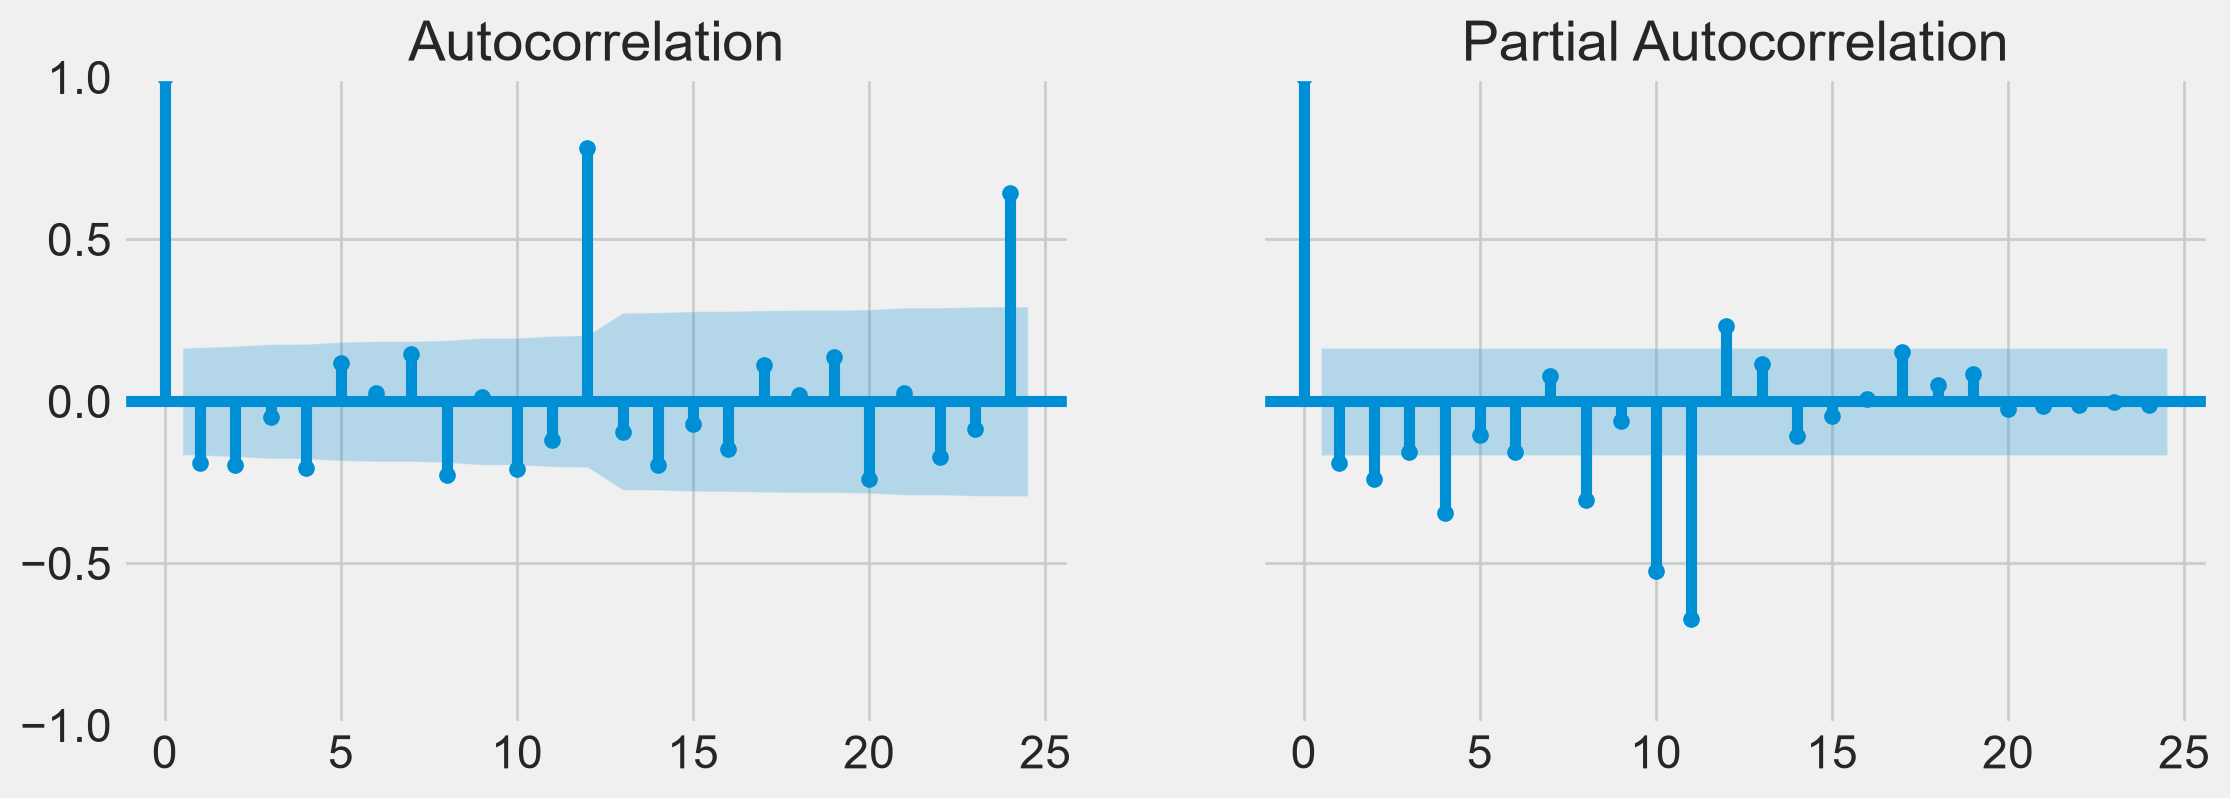

In [15]:
# Plot ACF and PACF on the differenced series, lags=24
autocorr_plots(df['diff_2'].dropna(), lags=24);

**Based on the plots above, what would you guess for `p` and `q`?**

- p (AR terms): The PACF cuts off sharply after lag 1 (with another spike around lag 2-4), suggesting a low-order AR term, roughly **p ≈ 1-2**.
- q (MA terms): The ACF shows a sharp cutoff after lag 1, with a strong negative spike, suggesting **q ≈ 1**.

So a reasonable manual starting guess is something like ARIMA(1,2,1) or ARIMA(2,2,1). We'll let `auto_arima` search more formally in the next step.

### A4. Confirm with auto_arima

Now check your manual guess against `auto_arima`. Keep `seasonal=False` as we are not modeling seasonality in Part A.

In [16]:
# Run auto_arima with seasonal=False and print the summary
auto_model = auto_arima(df['thousands_of_passengers'],
                         seasonal=False,
                         trace=True,
                         suppress_warnings=True)
auto_model.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=1.04 sec
 ARIMA(0,1,0)(0,0,0)[0] intercept   : AIC=1415.278, Time=0.06 sec
 ARIMA(1,1,0)(0,0,0)[0] intercept   : AIC=1403.473, Time=0.13 sec
 ARIMA(0,1,1)(0,0,0)[0] intercept   : AIC=1398.827, Time=0.21 sec
 ARIMA(0,1,0)(0,0,0)[0]             : AIC=1413.909, Time=0.05 sec
 ARIMA(1,1,1)(0,0,0)[0] intercept   : AIC=1396.121, Time=0.37 sec
 ARIMA(2,1,1)(0,0,0)[0] intercept   : AIC=inf, Time=0.66 sec
 ARIMA(1,1,2)(0,0,0)[0] intercept   : AIC=inf, Time=0.39 sec
 ARIMA(0,1,2)(0,0,0)[0] intercept   : AIC=1398.386, Time=0.25 sec
 ARIMA(2,1,0)(0,0,0)[0] intercept   : AIC=1397.975, Time=0.17 sec
 ARIMA(1,1,1)(0,0,0)[0]             : AIC=1394.683, Time=0.14 sec
 ARIMA(0,1,1)(0,0,0)[0]             : AIC=1397.258, Time=0.09 sec
 ARIMA(1,1,0)(0,0,0)[0]             : AIC=1401.852, Time=0.10 sec
 ARIMA(2,1,1)(0,0,0)[0]             : AIC=1378.338, Time=0.18 sec
 ARIMA(2,1,0)(0,0,0)[0]             : AIC=1396.5

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                  144
Model:               SARIMAX(4, 1, 3)   Log Likelihood                -674.913
Date:                Thu, 13 Aug 2026   AIC                           1365.825
Time:                        09:18:30   BIC                           1389.528
Sample:                    01-01-1949   HQIC                          1375.457
                         - 12-01-1960                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5582      0.117     -4.782      0.000      -0.787      -0.329
ar.L2          0.4935      0.113      4.375      0.000       0.272       0.715
ar.L3          0.1238      0.128      0.970      0.332      -0.126       0.374
ar.L4         -0.5213      0.085     -6.136      0.000      -0.688      -0.355
ma.L1          0.9069      0.094      9.657      0.000       0.723       1.091
ma.L2         -0.5590      0.145     -3.866      0.000      -0.842      -0.276
ma.L3         -0.7385      0.109     -6.778      0.000      -0.952      -0.525
sigma2       724.1716     85.615      8.458      0.000     556.368     891.975
===================================================================================
Ljung-Box (L1) (Q):                   0.37   Jarque-Bera (JB):                14.59
Prob(Q):                              0.54   Prob(JB):                         0.00
Heteroskedasticity (H):               5.66   Skew:                             0.74
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.52
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### A5. Train, Test, and Split

Hold out the last 12 months as your test set.

In [17]:
# Split into df_train (all but last 12 rows) and df_test (last 12 rows)
df_train = df.iloc[:-12]
df_test = df.iloc[-12:]
len(df_train), len(df_test)

(132, 12)

### A6. Fit the ARIMA model

Use the (p,d,q) order from A4.

In [29]:
# Fit ARIMA(p,d,q) on the training set
arima_order = auto_model.order
print("Using order:", arima_order)

model_arima = ARIMA(
    df_train["thousands_of_passengers"],
    order=arima_order,
    enforce_stationarity=False,
    enforce_invertibility=False
)

results_arima = model_arima.fit()

print(results_arima.summary())

Using order: (4, 1, 3)
                                  SARIMAX Results                                  
Dep. Variable:     thousands_of_passengers   No. Observations:                  132
Model:                      ARIMA(4, 1, 3)   Log Likelihood                -590.867
Date:                     Thu, 13 Aug 2026   AIC                           1197.735
Time:                             09:21:31   BIC                           1220.488
Sample:                         01-01-1949   HQIC                          1206.979
                              - 12-01-1959                                         
Covariance Type:                       opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5646      0.117     -4.818      0.000      -0.794      -0.335
ar.L2          0.4795      0.127      3.771      0.000       0.230  

In [18]:
# Fit ARIMA(p,d,q) on the training set
arima_order = auto_model.order   # (p,d,q) suggested by auto_arima
print('Using order:', arima_order)

model_arima = ARIMA(df_train['thousands_of_passengers'], order=arima_order)
results_arima = model_arima.fit()
results_arima.summary()

Using order: (4, 1, 3)


C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


<class 'statsmodels.iolib.summary.Summary'>
"""
                                  SARIMAX Results                                  
===================================================================================
Dep. Variable:     thousands_of_passengers   No. Observations:                  132
Model:                      ARIMA(4, 1, 3)   Log Likelihood                -607.206
Date:                     Thu, 13 Aug 2026   AIC                           1230.412
Time:                             09:19:09   BIC                           1253.414
Sample:                         01-01-1949   HQIC                          1239.759
                              - 12-01-1959                                         
Covariance Type:                       opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5693      0.115     -4.968      0.000      -0.794      -0.345
ar.L2          0.4828      0.123      3.935      0.000       0.242       0.723
ar.L3          0.1164      0.128      0.911      0.362      -0.134       0.367
ar.L4         -0.5331      0.084     -6.378      0.000      -0.697      -0.369
ma.L1          0.9304      0.103      8.994      0.000       0.728       1.133
ma.L2         -0.5541      0.151     -3.670      0.000      -0.850      -0.258
ma.L3         -0.7290      0.102     -7.155      0.000      -0.929      -0.529
sigma2       607.4737     76.263      7.965      0.000     458.000     756.947
===================================================================================
Ljung-Box (L1) (Q):                   0.20   Jarque-Bera (JB):                11.03
Prob(Q):                              0.65   Prob(JB):                         0.00
Heteroskedasticity (H):               4.40   Skew:                             0.69
Prob(H) (two-sided):                  0.00   Kurtosis:                         3.38
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### A7. Predict on the test set

In [19]:
# Predict over the test period
start = len(df_train)
end = len(df_train) + len(df_test) - 1

predictions_arima = results_arima.predict(start=start, end=end).rename('ARIMA Predictions')
predictions_arima.index = df_test.index
predictions_arima

month
1960-01-01    441.014235
1960-02-01    446.034156
1960-03-01    469.988827
1960-04-01    440.043186
1960-05-01    450.040036
1960-06-01    430.002108
1960-07-01    429.978877
1960-08-01    437.445814
1960-09-01    425.521795
1960-10-01    446.595412
1960-11-01    429.723129
1960-12-01    444.134240
Freq: MS, Name: ARIMA Predictions, dtype: float64

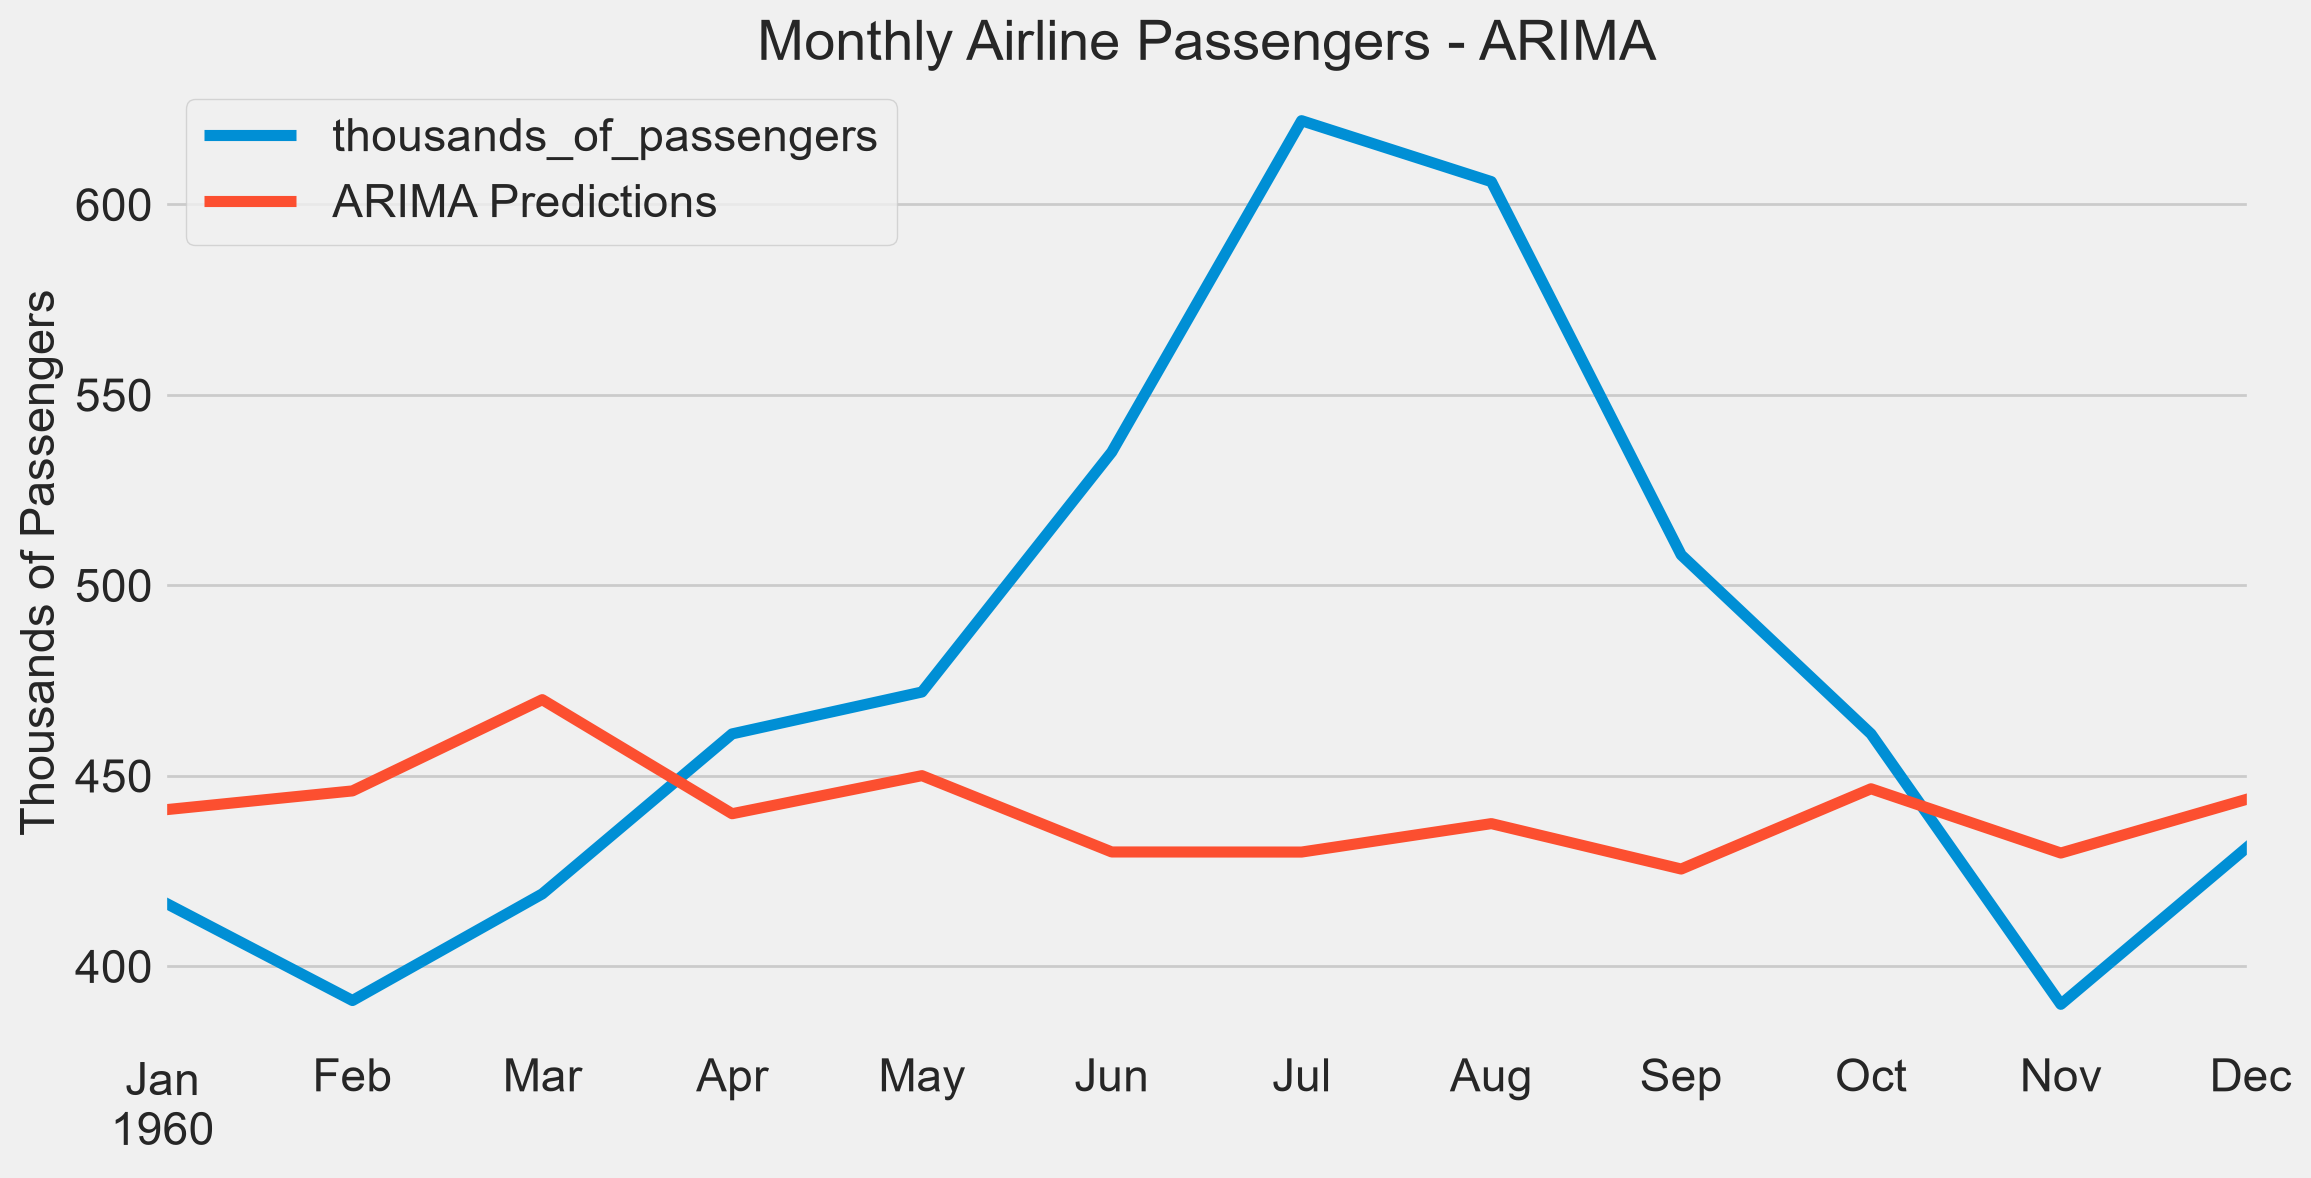

In [20]:
# Plot the test data vs predictions
title = 'Monthly Airline Passengers - ARIMA'
ylabel = 'Thousands of Passengers'
xlabel = ''

ax = df_test['thousands_of_passengers'].plot(legend=True, figsize=(12,6), title=title)
predictions_arima.plot(legend=True)
ax.autoscale(axis='x', tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel);

### A8. Evaluate

Compute RMSE for the ARIMA model. Also print the mean of the series so you have something to compare the error against.

In [21]:
# Compute RMSE
error_arima = rmse(df_test['thousands_of_passengers'], predictions_arima)
print(f'ARIMA{arima_order} RMSE Error: {error_arima:.3f}')
print(f'Mean of series: {df["thousands_of_passengers"].mean():.3f}')

ARIMA(4, 1, 3) RMSE Error: 87.640
Mean of series: 280.299


---
# Part B - SARIMA

Now let's actually look at *why* the ARIMA forecast missed. This is where we introduce seasonality.


### B1. Seasonal decomposition

Run `seasonal_decompose` on the **original** (undifferenced) series and plot it.

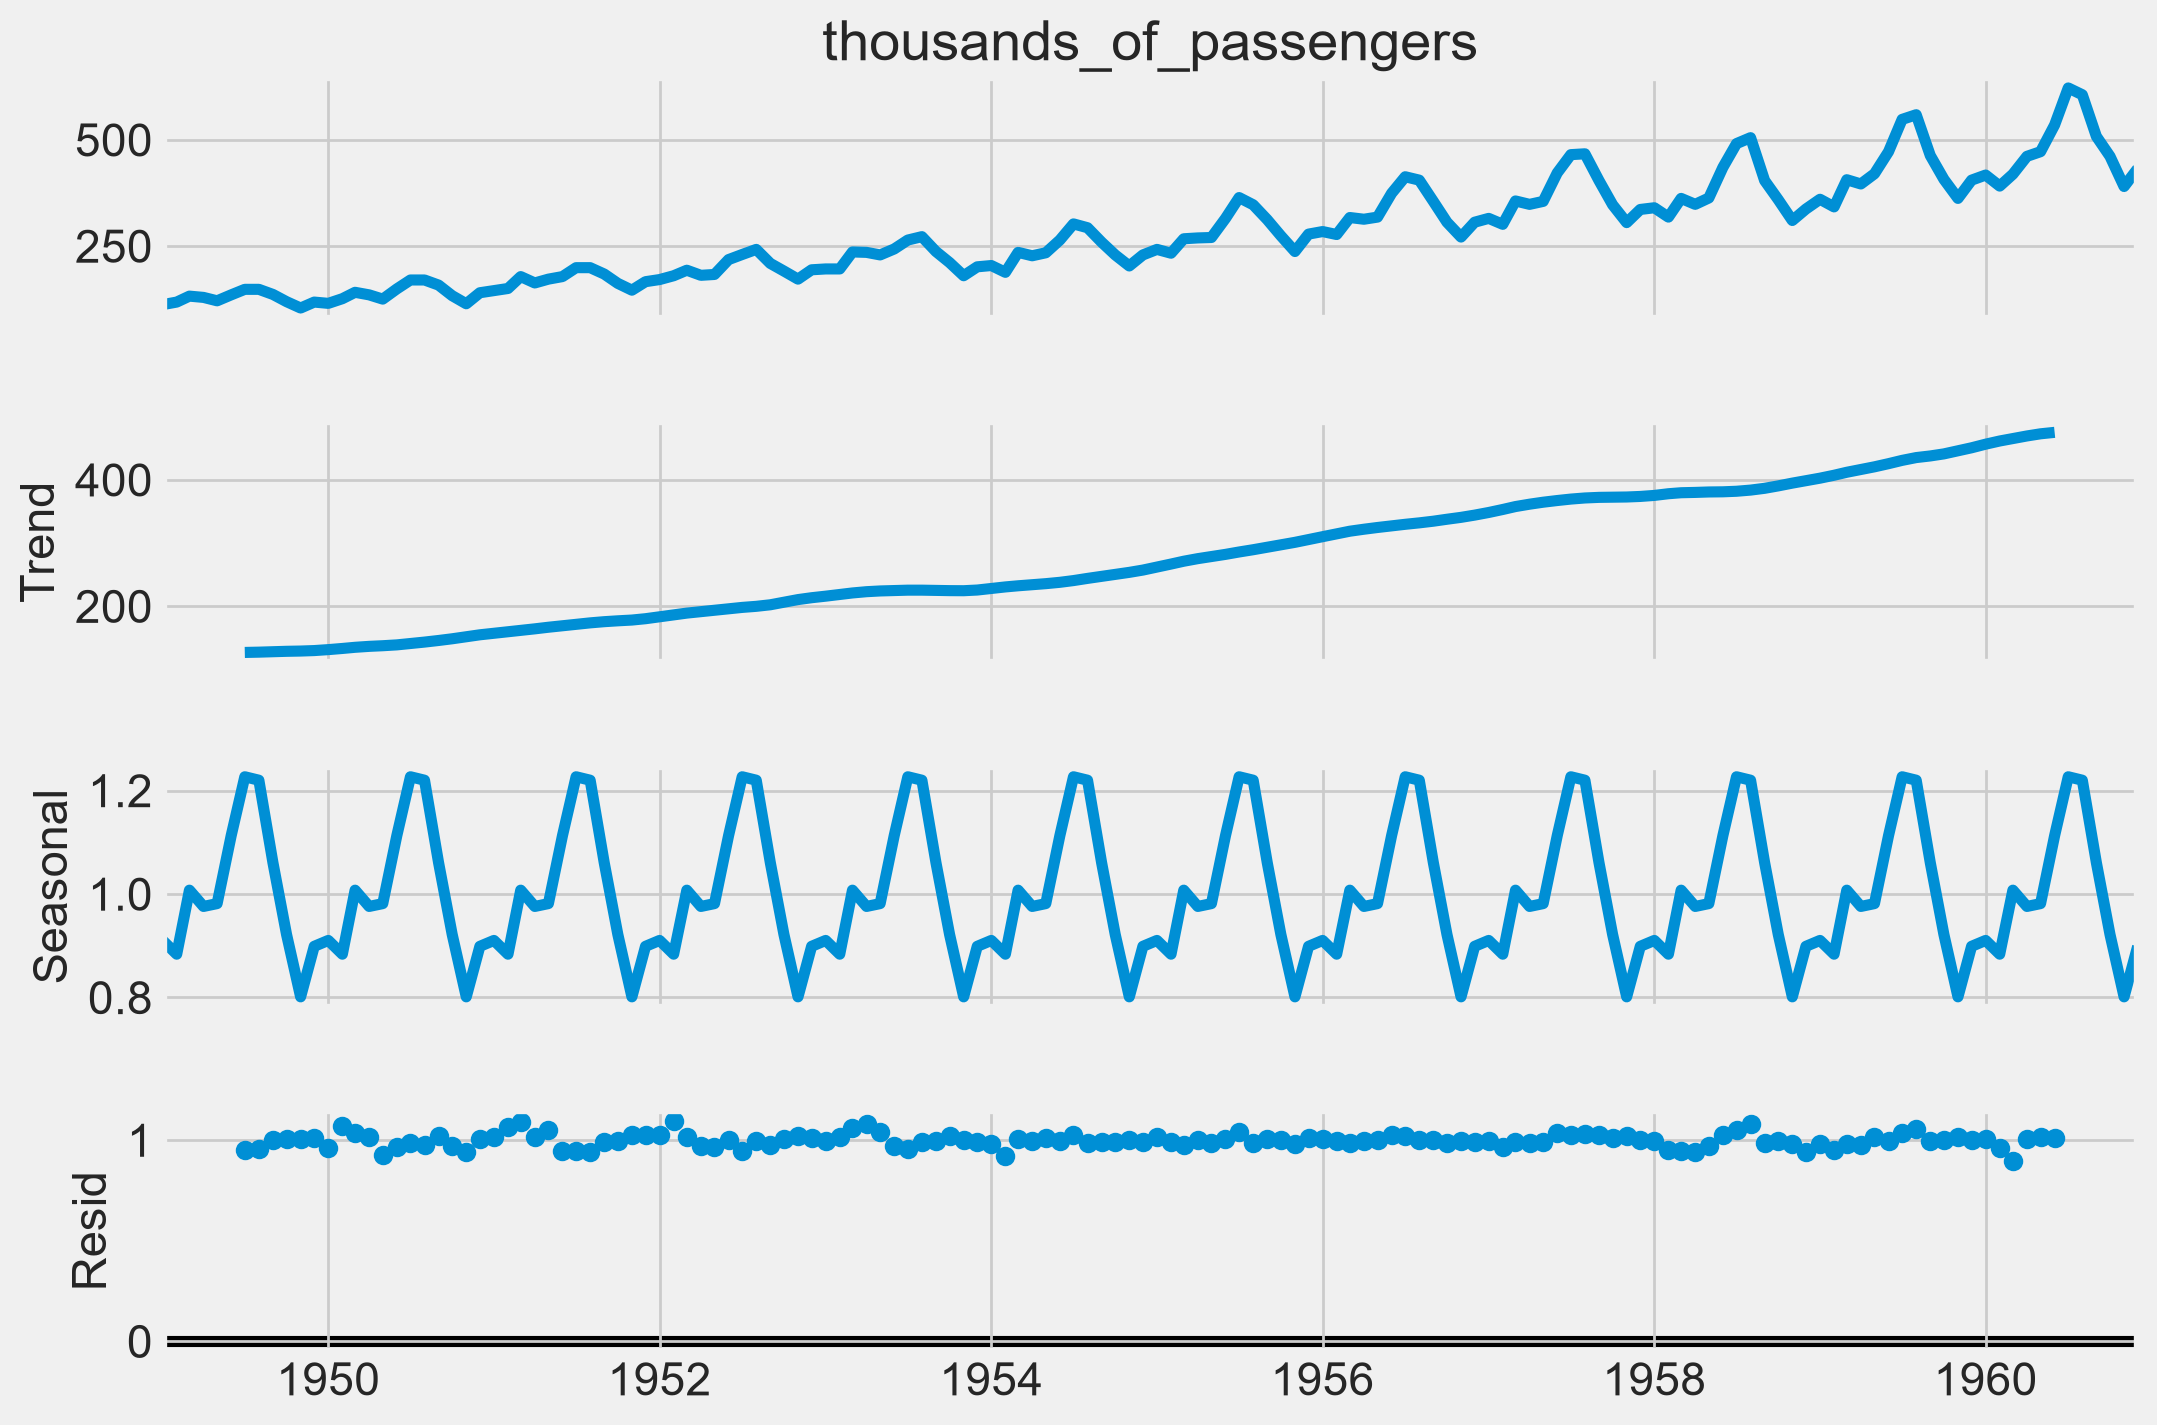

In [22]:
result = seasonal_decompose(df['thousands_of_passengers'], model='multiplicative')
fig = result.plot()
fig.set_size_inches(12, 8)
plt.show()

**What do you see in the seasonal component?** Is there a repeating pattern? What's the period (how many months before it repeats)?

Yes -- the seasonal component shows a clear, repeating pattern that completes one full cycle every **12 months**: passenger traffic peaks around July/August (summer travel) and dips in November. This pattern repeats identically year after year, and its amplitude grows over time (visible in the multiplicative decomposition and the widening swings in the original series), confirming there's a real, strong 12-month seasonal cycle that ARIMA alone can't capture.

### B2. Search for a seasonal order with auto_arima

Run `auto_arima` again, this time with `seasonal=True` and `m=12` (12 months per cycle).

In [23]:
auto_seasonal_model = auto_arima(df['thousands_of_passengers'],
                                  seasonal=True,
                                  m=12,
                                  trace=True,
                                  suppress_warnings=True)
auto_seasonal_model.summary()

Performing stepwise search to minimize aic
 ARIMA(2,1,2)(1,1,1)[12]             : AIC=1020.048, Time=1.82 sec
 ARIMA(0,1,0)(0,1,0)[12]             : AIC=1031.508, Time=0.06 sec
 ARIMA(1,1,0)(1,1,0)[12]             : AIC=1020.393, Time=0.19 sec
 ARIMA(0,1,1)(0,1,1)[12]             : AIC=1021.003, Time=0.27 sec
 ARIMA(2,1,2)(0,1,1)[12]             : AIC=1019.935, Time=0.98 sec
 ARIMA(2,1,2)(0,1,0)[12]             : AIC=1019.290, Time=0.35 sec
 ARIMA(2,1,2)(1,1,0)[12]             : AIC=1019.546, Time=1.01 sec
 ARIMA(1,1,2)(0,1,0)[12]             : AIC=1024.160, Time=0.18 sec
 ARIMA(2,1,1)(0,1,0)[12]             : AIC=1017.847, Time=0.32 sec
 ARIMA(2,1,1)(1,1,0)[12]             : AIC=1017.914, Time=0.97 sec
 ARIMA(2,1,1)(0,1,1)[12]             : AIC=1018.359, Time=0.88 sec
 ARIMA(2,1,1)(1,1,1)[12]             : AIC=1018.248, Time=1.80 sec
 ARIMA(1,1,1)(0,1,0)[12]             : AIC=1022.393, Time=0.13 sec
 ARIMA(2,1,0)(0,1,0)[12]             : AIC=1022.393, Time=0.15 sec
 ARIMA(3,1,1)(0,1,0

<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:                                   y   No. Observations:                  144
Model:             SARIMAX(2, 1, 1)x(0, 1, [], 12)   Log Likelihood                -504.923
Date:                             Thu, 13 Aug 2026   AIC                           1017.847
Time:                                     09:19:42   BIC                           1029.348
Sample:                                 01-01-1949   HQIC                          1022.520
                                      - 12-01-1960                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.5960      0.085      6.987      0.000       0.429       0.763
ar.L2          0.2143      0.091      2.343      0.019       0.035       0.393
ma.L1         -0.9819      0.038    -25.600      0.000      -1.057      -0.907
sigma2       129.3095     14.556      8.884      0.000     100.781     157.838
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 7.68
Prob(Q):                              0.98   Prob(JB):                         0.02
Heteroskedasticity (H):               2.33   Skew:                            -0.01
Prob(H) (two-sided):                  0.01   Kurtosis:                         4.19
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

**Write down the order and seasonal_order suggested:**

- order (p,d,q) = (2, 1, 1)
- seasonal_order (P,D,Q,m) = (0, 1, 0, 12)

### B3. Fit the SARIMA model

Use `SARIMAX` with both `order` and `seasonal_order`, fit on `df_train`.

In [24]:
sarima_order = auto_seasonal_model.order
sarima_seasonal_order = auto_seasonal_model.seasonal_order
print('Using order:', sarima_order, ' seasonal_order:', sarima_seasonal_order)

model_sarima = SARIMAX(df_train['thousands_of_passengers'],
                        order=sarima_order,
                        seasonal_order=sarima_seasonal_order)
results_sarima = model_sarima.fit()
results_sarima.summary()

Using order: (2, 1, 1)  seasonal_order: (0, 1, 0, 12)


C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


<class 'statsmodels.iolib.summary.Summary'>
"""
                                      SARIMAX Results                                      
===========================================================================================
Dep. Variable:             thousands_of_passengers   No. Observations:                  132
Model:             SARIMAX(2, 1, 1)x(0, 1, [], 12)   Log Likelihood                -447.483
Date:                             Thu, 13 Aug 2026   AIC                            902.967
Time:                                     09:19:43   BIC                            914.083
Sample:                                 01-01-1949   HQIC                           907.481
                                      - 12-01-1959                                         
Covariance Type:                               opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.5252      0.928     -0.566      0.572      -2.345       1.295
ar.L2          0.0110      0.275      0.040      0.968      -0.529       0.551
ma.L1          0.3064      0.935      0.328      0.743      -1.527       2.139
sigma2       108.0093     13.498      8.002      0.000      81.553     134.466
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                 1.39
Prob(Q):                              0.97   Prob(JB):                         0.50
Heteroskedasticity (H):               1.47   Skew:                            -0.09
Prob(H) (two-sided):                  0.23   Kurtosis:                         3.50
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

### B4. Predict on the test set, with confidence intervals

This time, also pull the confidence interval so you can plot forecast uncertainty.

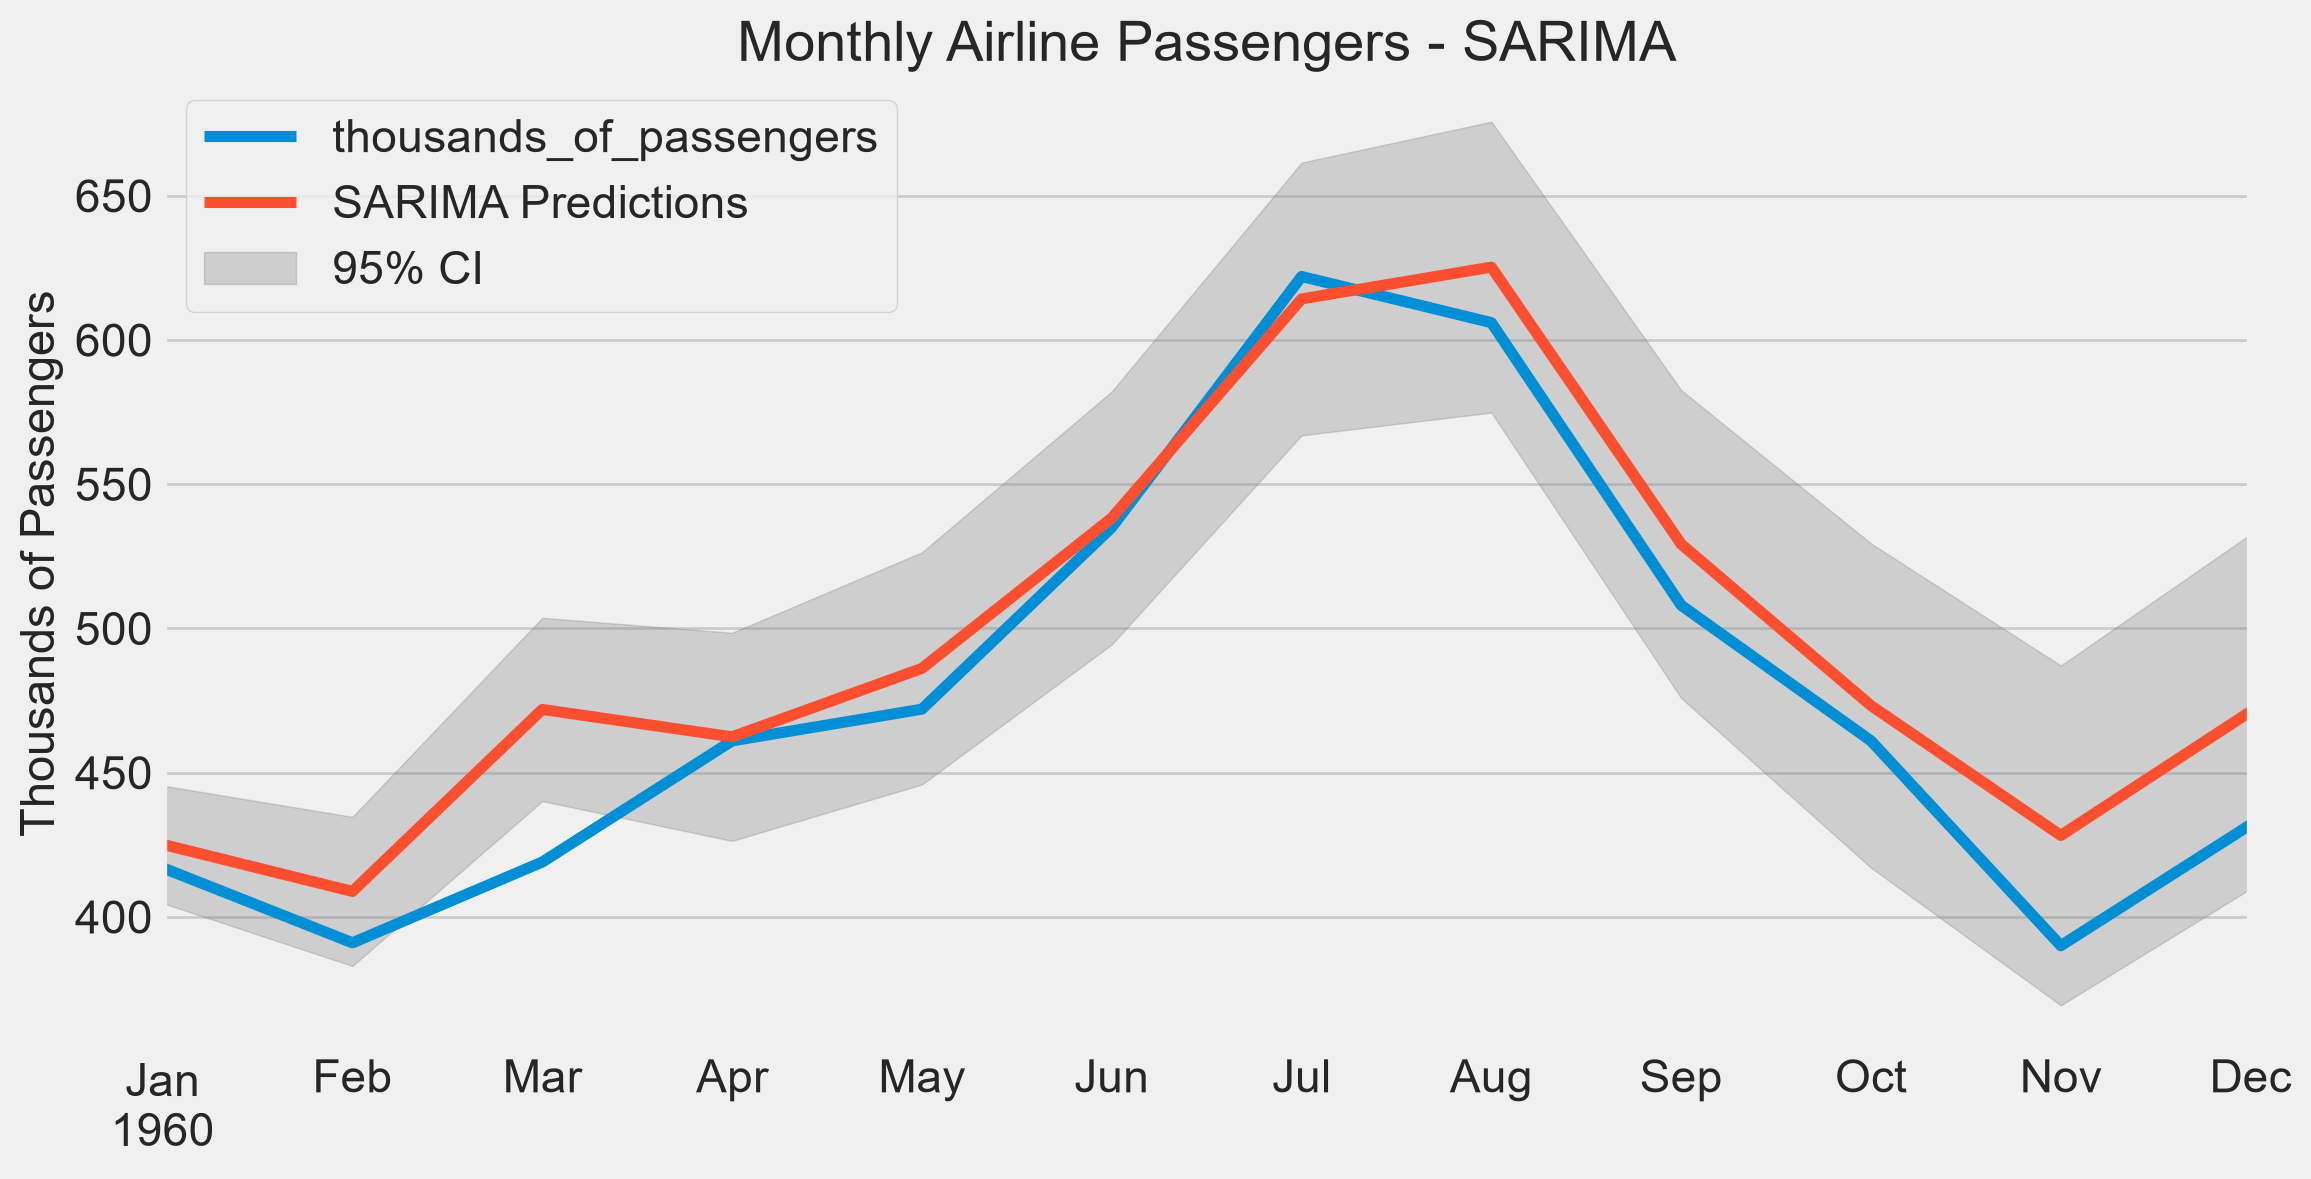

In [25]:
pred_obj_sarima = results_sarima.get_prediction(start=start, end=end)
predictions_sarima = pred_obj_sarima.predicted_mean.rename('SARIMA Predictions')
predictions_sarima.index = df_test.index

ci_sarima = pred_obj_sarima.conf_int()
ci_sarima.index = df_test.index

title = 'Monthly Airline Passengers - SARIMA'
ylabel = 'Thousands of Passengers'
xlabel = ''

ax = df_test['thousands_of_passengers'].plot(legend=True, figsize=(12,6), title=title)
predictions_sarima.plot(legend=True)
ax.fill_between(ci_sarima.index, ci_sarima.iloc[:, 0], ci_sarima.iloc[:, 1], color='gray', alpha=0.3, label='95% CI')
ax.autoscale(axis='x', tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)
ax.legend();

### B5. Evaluate

In [26]:
# Compute RMSE
error_sarima = rmse(df_test['thousands_of_passengers'], predictions_sarima)
print(f'SARIMA{sarima_order}{sarima_seasonal_order} RMSE Error: {error_sarima:.3f}')

SARIMA(2, 1, 1)(0, 1, 0, 12) RMSE Error: 24.874


### B6. ARIMA vs. SARIMA

Plot both sets of predictions against the actual test values side by side and print both RMSEs together.

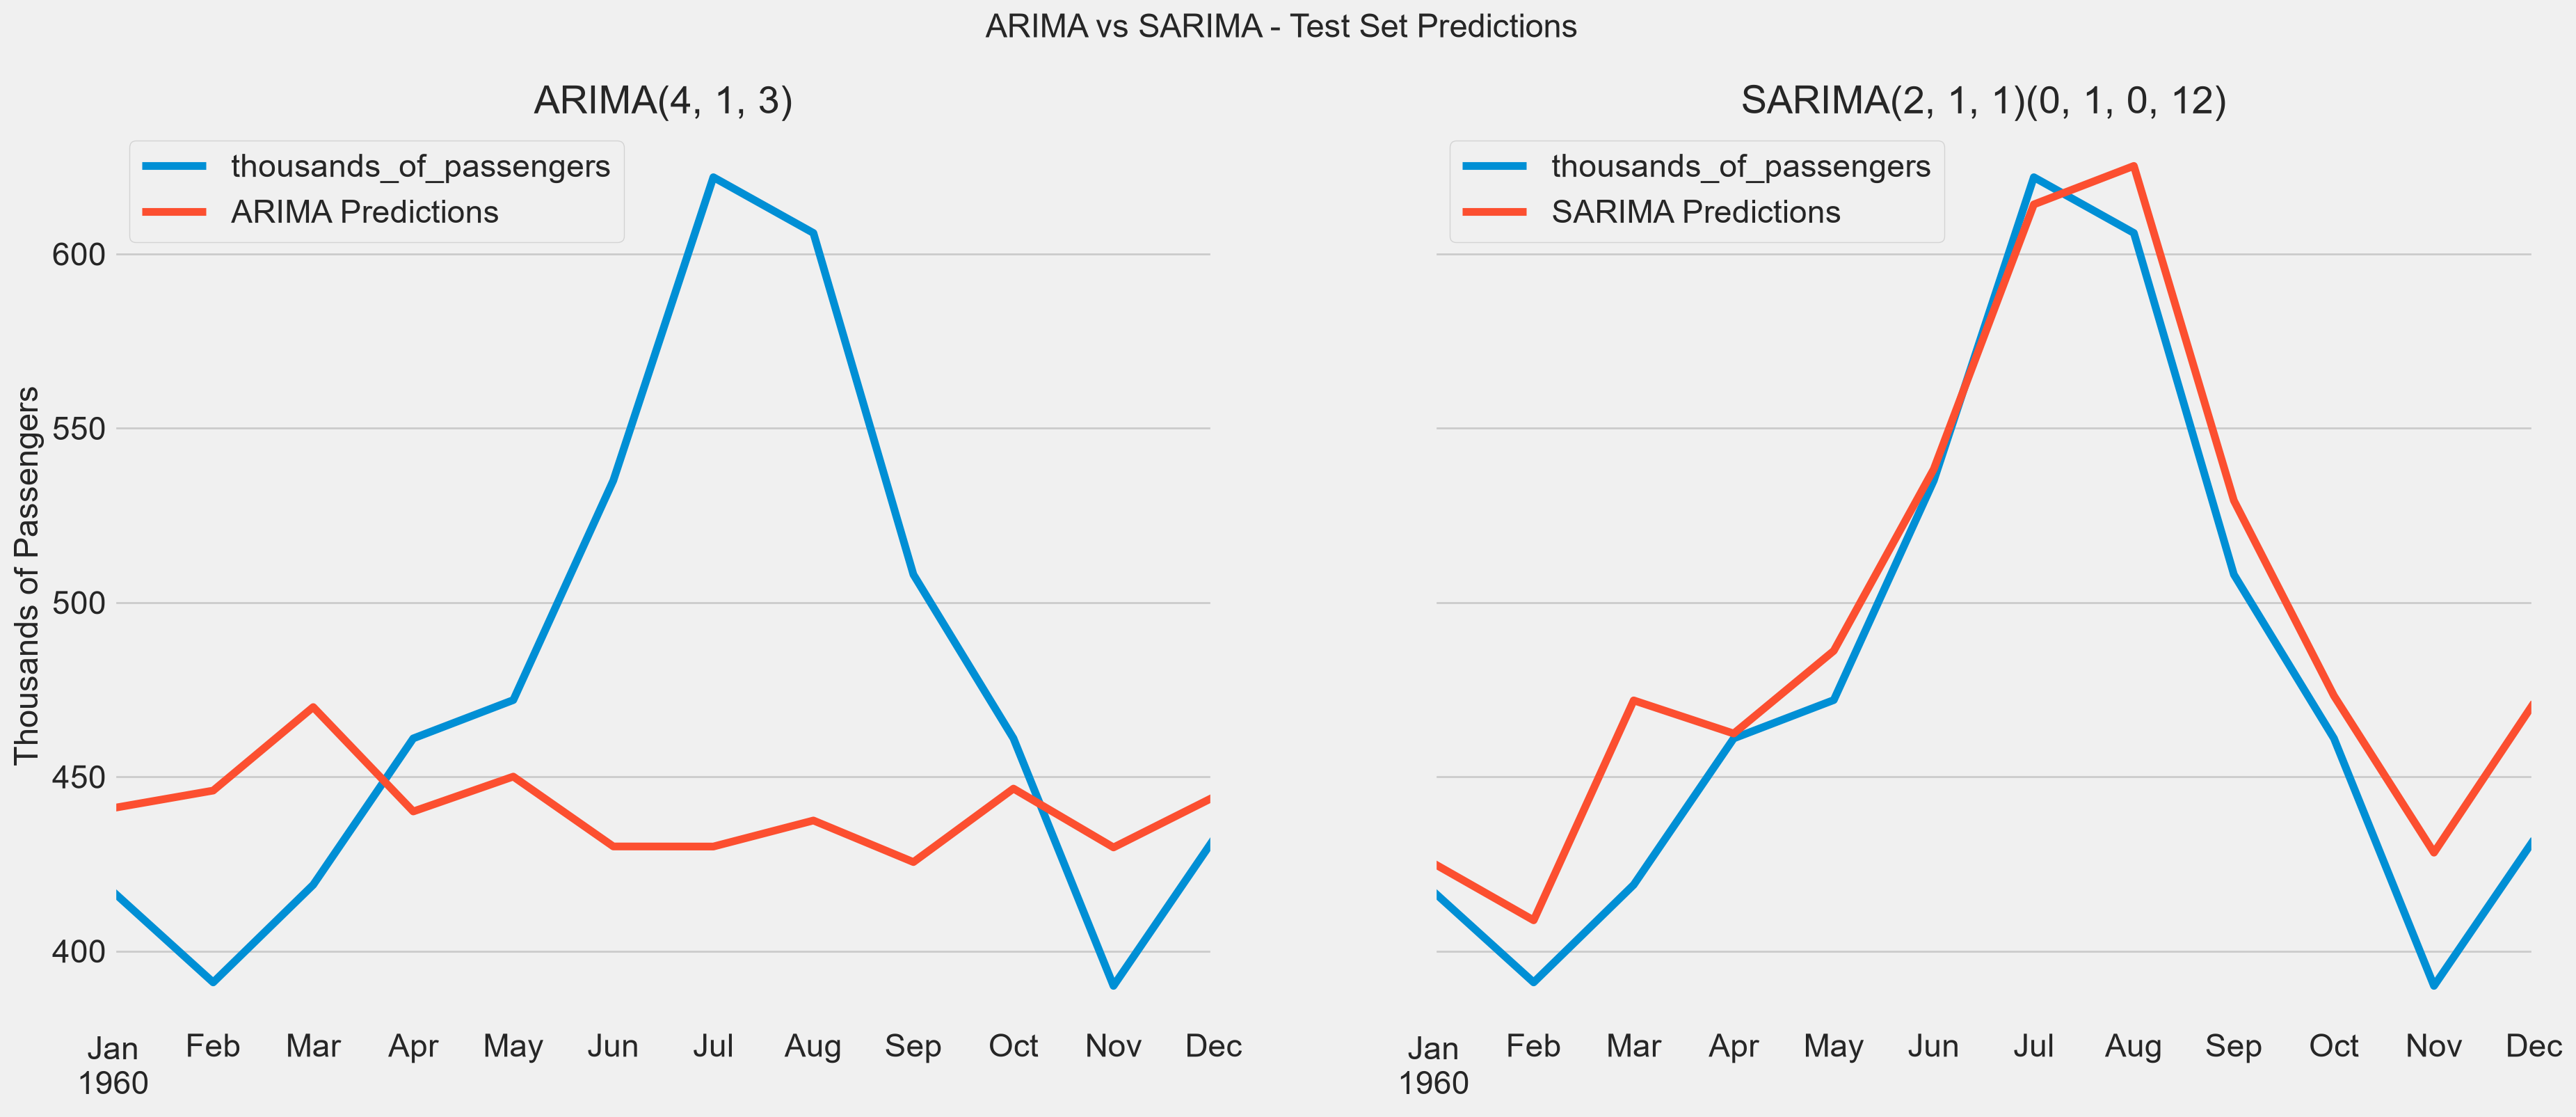

ARIMA(4, 1, 3) RMSE:  87.640
SARIMA(2, 1, 1)(0, 1, 0, 12) RMSE: 24.874

SARIMA reduces RMSE by 71.6% compared to ARIMA.


In [27]:
fig, ax = plt.subplots(ncols=2, figsize=(20, 8), sharey=True)

df_test['thousands_of_passengers'].plot(legend=True, ax=ax[0], title=f'ARIMA{arima_order}')
predictions_arima.plot(legend=True, ax=ax[0])
ax[0].autoscale(axis='x', tight=True)
ax[0].set(xlabel='', ylabel='Thousands of Passengers')

df_test['thousands_of_passengers'].plot(legend=True, ax=ax[1], title=f'SARIMA{sarima_order}{sarima_seasonal_order}')
predictions_sarima.plot(legend=True, ax=ax[1])
ax[1].autoscale(axis='x', tight=True)
ax[1].set(xlabel='', ylabel='')
plt.suptitle('ARIMA vs SARIMA - Test Set Predictions')
plt.show()

print(f'ARIMA{arima_order} RMSE:  {error_arima:.3f}')
print(f'SARIMA{sarima_order}{sarima_seasonal_order} RMSE: {error_sarima:.3f}')
print(f'\nSARIMA reduces RMSE by {(1 - error_sarima/error_arima)*100:.1f}% compared to ARIMA.')

<a id='forecast'></a>
## 2. Forecast the future

Retrain your **winning model** on the *full* dataset and forecast 12 months into the future

**Bonus**: *Plot the forecast with confidence intervals*.

C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
C:\Users\user\AppData\Local\Programs\Python\Python312\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


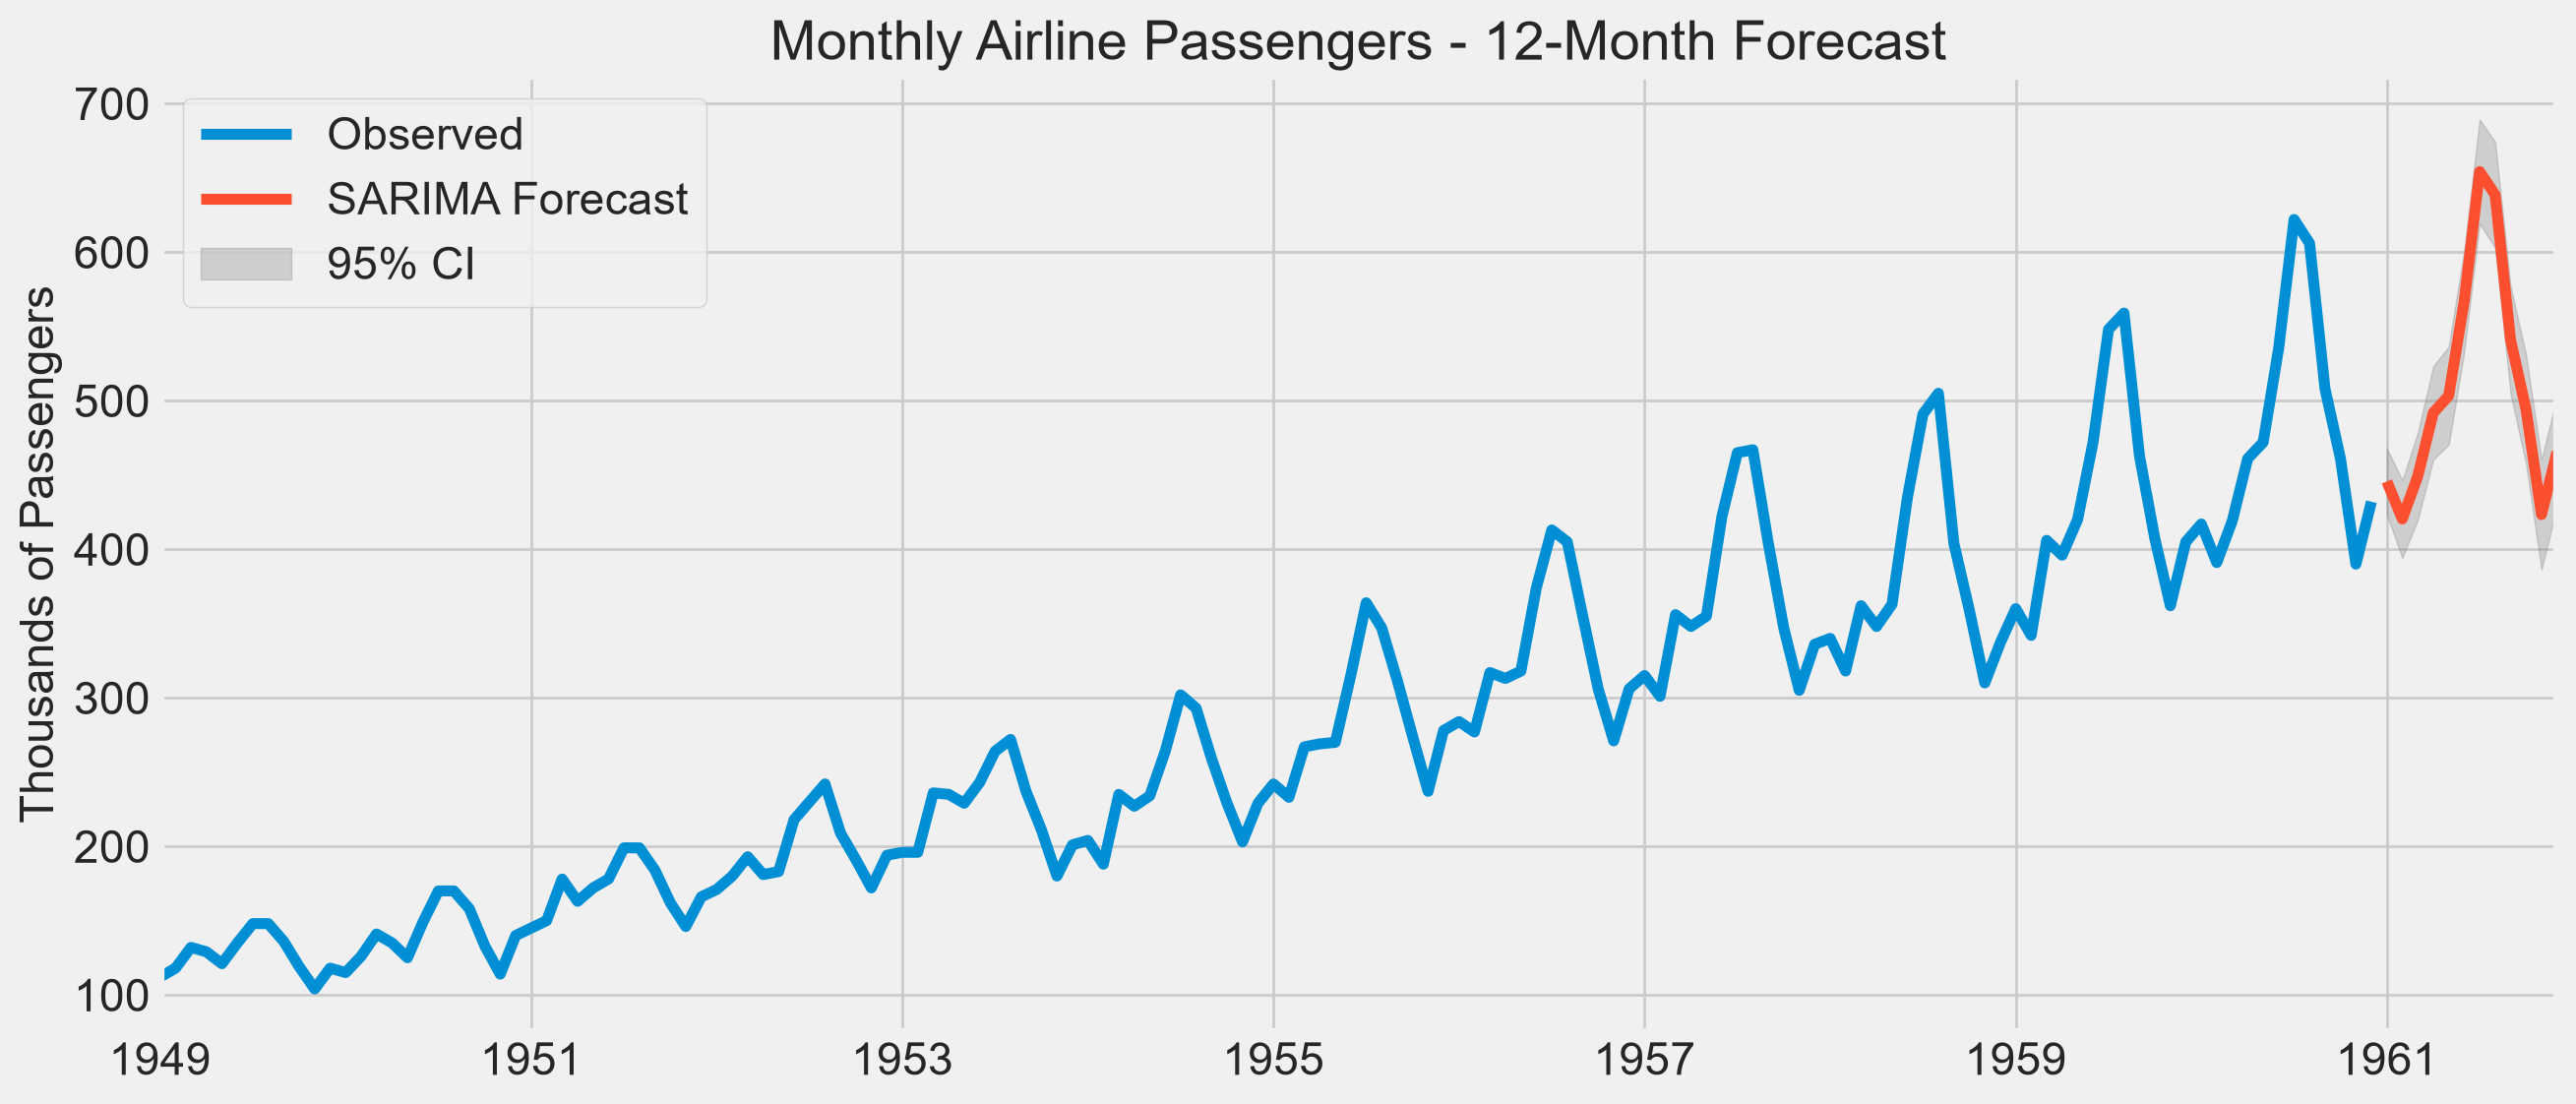

1961-01-01    445.635490
1961-02-01    420.395892
1961-03-01    449.199502
1961-04-01    491.841353
1961-05-01    503.396060
1961-06-01    566.864173
1961-07-01    654.262007
1961-08-01    638.599403
1961-09-01    540.885722
1961-10-01    494.128651
1961-11-01    423.334776
1961-12-01    465.509671
Freq: MS, Name: SARIMA Forecast, dtype: float64

In [28]:
# SARIMA was the clear winner (much lower RMSE), so retrain it on the FULL dataset
final_model = SARIMAX(df['thousands_of_passengers'],
                       order=sarima_order,
                       seasonal_order=sarima_seasonal_order)
final_results = final_model.fit()

forecast_obj = final_results.get_forecast(steps=12)
forecast = forecast_obj.predicted_mean.rename('SARIMA Forecast')
forecast_ci = forecast_obj.conf_int()

title = 'Monthly Airline Passengers - 12-Month Forecast'
ylabel = 'Thousands of Passengers'
xlabel = ''

ax = df['thousands_of_passengers'].plot(legend=True, figsize=(14,6), title=title, label='Observed')
forecast.plot(legend=True, ax=ax)
ax.fill_between(forecast_ci.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='gray', alpha=0.3, label='95% CI')
ax.autoscale(axis='x', tight=True)
ax.set(xlabel=xlabel, ylabel=ylabel)
ax.legend()
plt.show()

forecast

## Takeaways
- Seasonality is easy to miss if you don't plot/decompose the data, hence, always look before you model.
- SARIMA isn't automatically the right call; it's justified when the seasonal component is real and the added parameters actually reduce error on held-out data.
- Always evaluate on a proper time-ordered train,test, and split.


## Additional Resources
- [statsmodels SARIMAX documentation](https://www.statsmodels.org/stable/generated/statsmodels.tsa.statespace.sarimax.SARIMAX.html)
- [pmdarima auto_arima documentation](https://alkaline-ml.com/pmdarima/modules/generated/pmdarima.arima.auto_arima.html)
- [Forecasting: Principles and Practice - Seasonal ARIMA](https://otexts.com/fpp2/seasonal-arima.html)
